
=== Evaluando modelo: LinearRegression ===
Best params: {'reg__fit_intercept': True}
Best CV score: 0.5062296484324464
Regression metrics (test):
MSE: 0.06982555454389643
MAE: 0.19776913543762892
R2: 0.5118966600973331

=== Evaluando modelo: Ridge ===
Best params: {'reg__alpha': 2, 'reg__fit_intercept': True}
Best CV score: 0.5062329547153185
Regression metrics (test):
MSE: 0.0698276749562811
MAE: 0.1977744889569705
R2: 0.5118818377250128

=== Evaluando modelo: Lasso ===
Best params: {'reg__alpha': 0.0025, 'reg__fit_intercept': True}
Best CV score: 0.48376190412456416
Regression metrics (test):
MSE: 0.07319961561274241
MAE: 0.20176810299809536
R2: 0.48831087567360987

=== Evaluando modelo: HistGradientBoostingRegressor ===
Best params: {'reg__l2_regularization': 0, 'reg__learning_rate': 0.1, 'reg__max_iter': 200, 'reg__max_leaf_nodes': 400, 'reg__min_samples_leaf': 30}
Best CV score: 0.601604299409454
Regression metrics (test):
MSE: 0.055875934780937435
MAE: 0.17336877880176377
R2: 0.

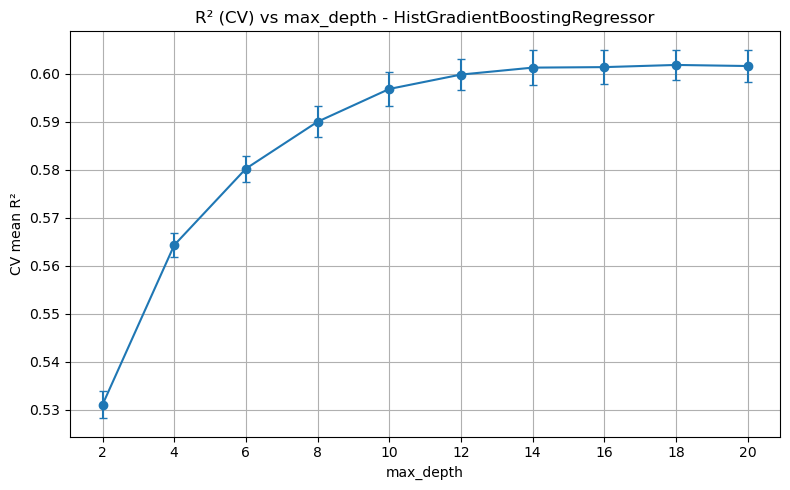

Best max_depth: 18
Best CV R²: 0.6017861152051424
Iteraciones muestreadas: 20 (cada 10)
Mejor iteración (entre muestreadas) por R² test: 200 (R²=0.6056)


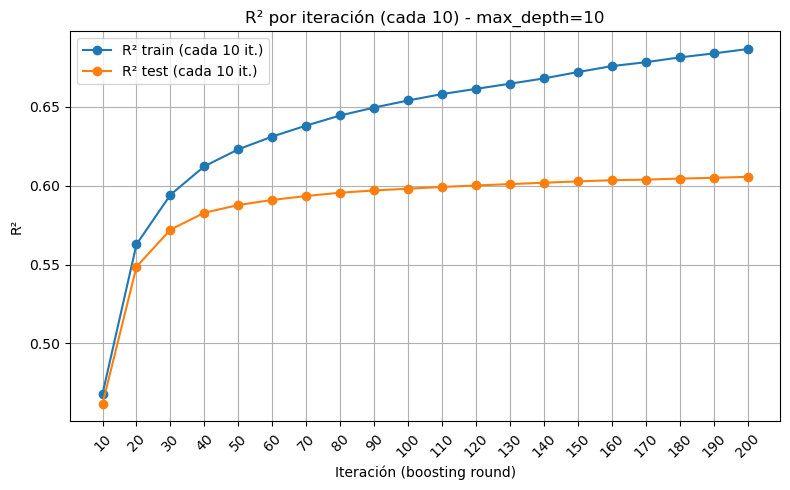

Haciendo grid search

=== Mejor configuración encontrada ===
{'reg__batch_size': 64, 'reg__hidden_layer_sizes': (64, 32), 'reg__max_iter': 100}

=== Métricas en test ===
Test MSE: 0.064974 | Test MAE: 0.191696 | Test R²: 0.545810
Entrenando el modelo en bloques de 5 iteraciones


c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


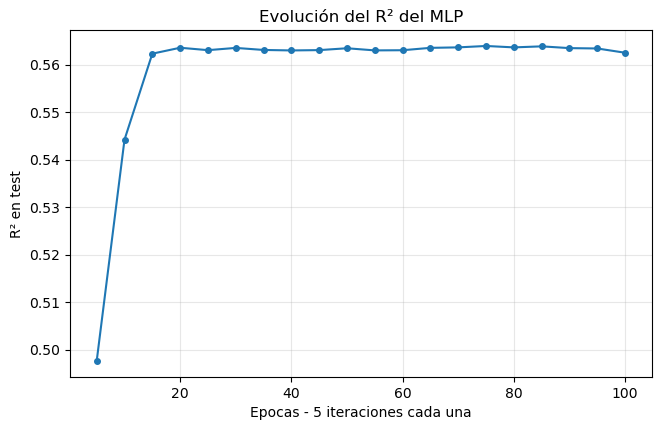

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import Feature_Engineering as FE
import matplotlib.pyplot as plt
import Deeper_Grid_Search as DGS
import Neural_Network as NN
import seaborn as sns

X_test,y_test = DGS.X_test,DGS.y_test
best_lr, best_hgb, best_ridge, best_lasso, best_mlp = DGS.best_lr, DGS.best_hgb, DGS.best_ridge, DGS.best_lasso, NN.best_model

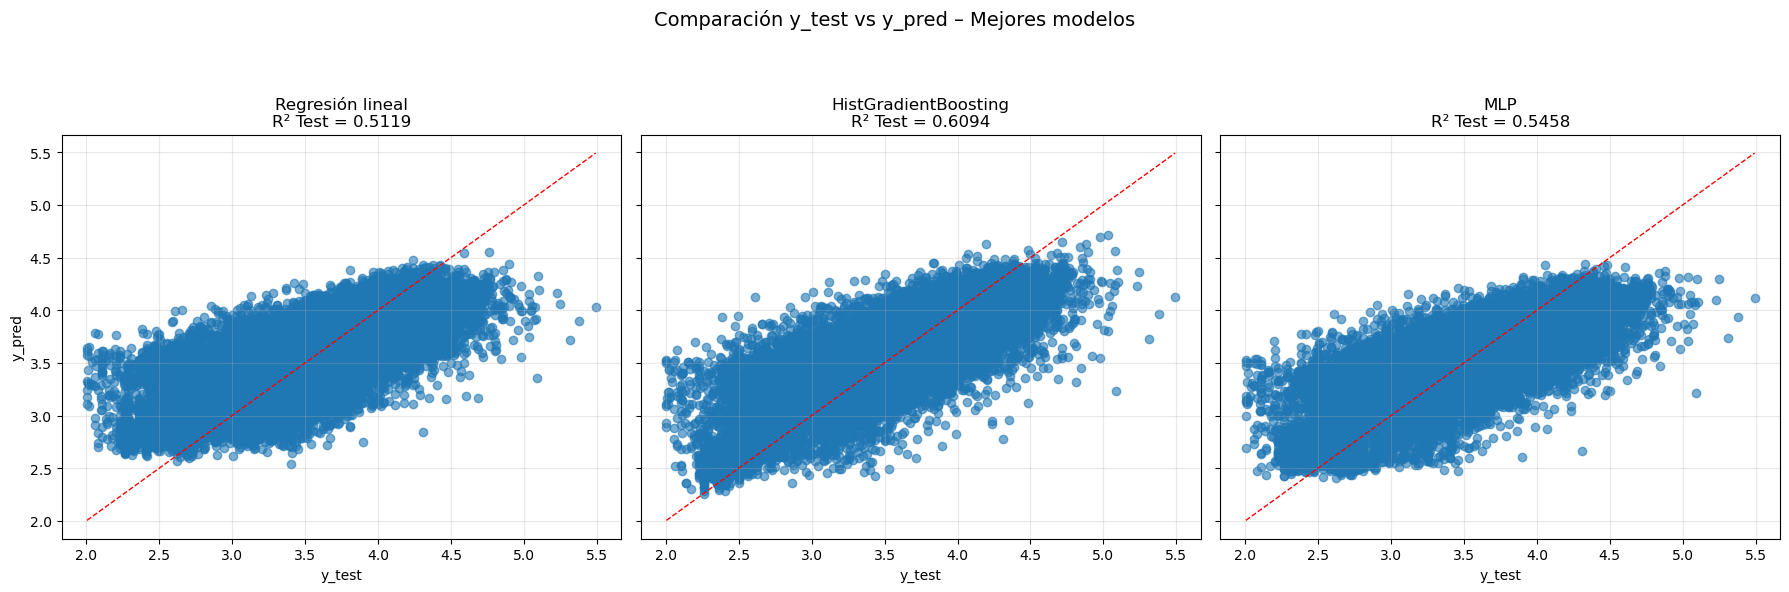

In [3]:
# Predicciones
y_pred_lr = best_lr.predict(X_test)
y_pred_hgb = best_hgb.predict(X_test)
y_pred_mlp = best_mlp.predict(X_test)

# Límites comunes
lims = [
    min(y_test.min(), y_pred_lr.min(), y_pred_hgb.min(), y_pred_mlp.min()),
    max(y_test.max(), y_pred_lr.max(), y_pred_hgb.max(), y_pred_mlp.max())
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

ax = axes[0]
ax.scatter(y_test, y_pred_lr, alpha=0.6)
ax.plot(lims, lims, 'r--', lw=1)
ax.set_title(f"Regresión lineal\nR² Test = {DGS.best_lr_r2:.4f}")
ax.set_xlabel("y_test")
ax.set_ylabel("y_pred")
ax.grid(True, alpha=0.3)

# ----- HistGradientBoosting -----
ax = axes[1]
ax.scatter(y_test, y_pred_hgb, alpha=0.6)
ax.plot(lims, lims, 'r--', lw=1)
ax.set_title(f"HistGradientBoosting\nR² Test = {DGS.best_hgb_r2:.4f}")
ax.set_xlabel("y_test")
ax.grid(True, alpha=0.3)

# ----- MLP -----
ax = axes[2]
ax.scatter(y_test, y_pred_mlp, alpha=0.6)
ax.plot(lims, lims, 'r--', lw=1)
ax.set_title(f"MLP\nR² Test = {NN.test_r2:.4f}")
ax.set_xlabel("y_test")
ax.grid(True, alpha=0.3)

# Título general
fig.suptitle(
    "Comparación y_test vs y_pred – Mejores modelos",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("Comparacion_Modelos_y_test_vs_y_pred.png", dpi=140)
plt.show()

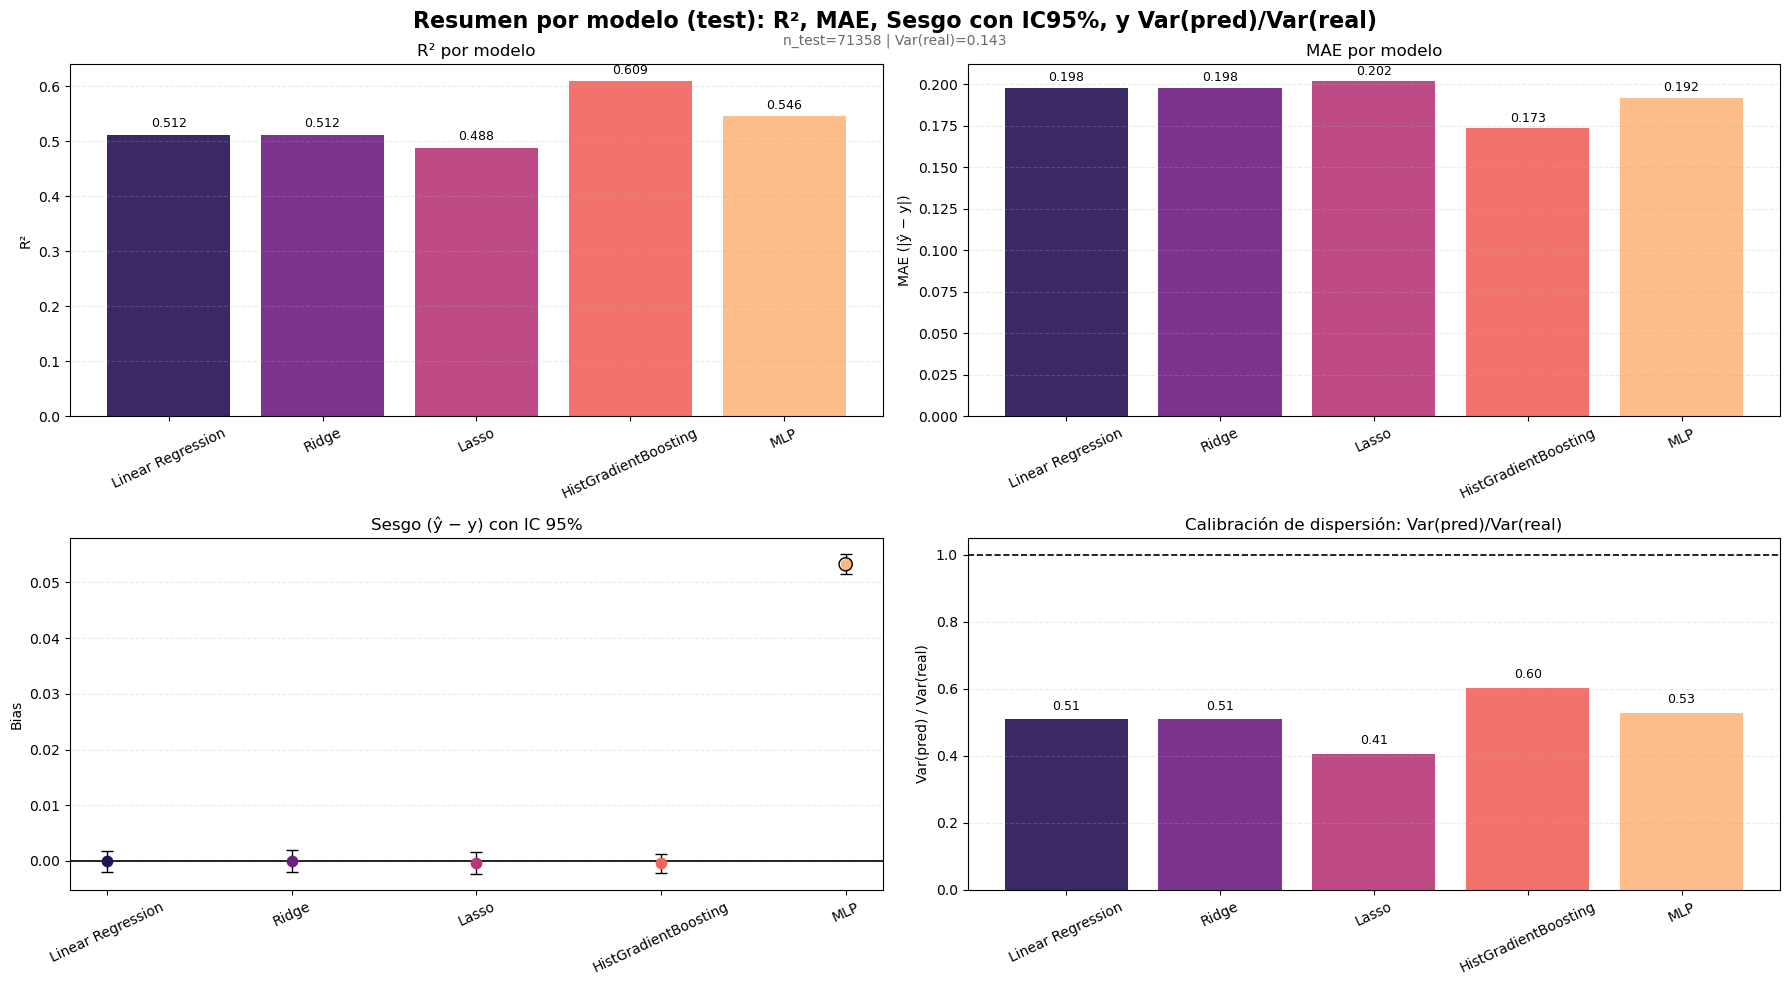

In [4]:
models_results = pd.DataFrame(np.vstack([DGS.res, NN.res_nn]), columns = DGS.colnames)
models_results.to_csv("model_comparison.csv", index=False)

var_real = np.var(y_test)
n_test   = len(y_test)

# CI95 del sesgo: bias ± 1.96 * sigma_e / sqrt(n)
sigma_e = np.sqrt(models_results["Varianza de Error en test"].to_numpy(float))
models_results["ci95"] = 1.96 * (sigma_e / np.sqrt(n_test))

# Ratio de dispersión: Var(pred)/Var(real)
models_results["var_ratio"] = models_results["Varianza en test"] / var_real

models = models_results["Modelo"].tolist()
x = np.arange(len(models))
colors = plt.cm.magma(np.linspace(0.15, 0.85, len(models)))

def add_bar_labels(ax, fmt="{:.2f}", dy=0.01):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.text(
                p.get_x() + p.get_width()/2, h + dy,
                fmt.format(h),
                ha="center", va="bottom", fontsize=9
            )

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
(ax1, ax2, ax3, ax4) = axes.flatten()

# (1) R²
ax1.bar(models, models_results["R2 en test"], color=colors, alpha=0.9)
ax1.set_title("R² por modelo")
ax1.set_ylabel("R²")
ax1.grid(axis="y", linestyle="--", alpha=0.25)
add_bar_labels(ax1, "{:.3f}", dy=0.008)
ax1.tick_params(axis="x", rotation=25)

# (2) MAE
ax2.bar(models, models_results["MAE en test"], color=colors, alpha=0.9)
ax2.set_title("MAE por modelo")
ax2.set_ylabel("MAE (|ŷ − y|)")
ax2.grid(axis="y", linestyle="--", alpha=0.25)
add_bar_labels(ax2, "{:.3f}", dy=0.002)
ax2.tick_params(axis="x", rotation=25)

# (3) Sesgo con IC95%
bias = models_results["Error Medio en test"].to_numpy(float)
ci95 = models_results["ci95"].to_numpy(float)

ax3.axhline(0, color="black", linewidth=1.2)
ax3.errorbar(
    x, bias, yerr=ci95,
    fmt="o", color="black", ecolor="black",
    capsize=4, elinewidth=1, markersize=6
)
for i in range(len(models)):
    ax3.scatter(i, bias[i], color=colors[i], s=55, zorder=3)

sig = (bias - ci95 > 0) | (bias + ci95 < 0)
ax3.scatter(x[sig], bias[sig], s=90, edgecolor="black",
            linewidth=1.0, facecolor="none", zorder=4)

ax3.set_title("Sesgo (ŷ − y) con IC 95%")
ax3.set_ylabel("Bias")
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=25)
ax3.grid(axis="y", linestyle="--", alpha=0.25)

# (4) Var(pred)/Var(real)
ratio = models_results["var_ratio"].to_numpy(float)
ax4.axhline(1.0, color="black", linewidth=1.2, linestyle="--")
ax4.bar(models, ratio, color=colors, alpha=0.9)
ax4.set_title("Calibración de dispersión: Var(pred)/Var(real)")
ax4.set_ylabel("Var(pred) / Var(real)")
ax4.grid(axis="y", linestyle="--", alpha=0.25)
add_bar_labels(ax4, "{:.2f}", dy=0.02)
ax4.tick_params(axis="x", rotation=25)

fig.suptitle("Resumen por modelo (test): R², MAE, Sesgo con IC95%, y Var(pred)/Var(real)",
             fontsize=16, fontweight="bold", y=0.98)

fig.text(0.5, 0.945, f"n_test={n_test} | Var(real)={var_real:.3f}",
         ha="center", fontsize=10, color="dimgray")

plt.tight_layout()
plt.savefig("model_comparison_summary.png")
plt.show()

In [24]:
print(X_test["P10"].value_counts())

P10
1    44361
2    25995
9     1002
Name: count, dtype: int64


In [25]:
X_test['age_group'] = pd.cut(X_test['P03'], bins=[-1, 17, 24, 40, 55, 100], labels=['-18', '18-25', '26-40', '41-55', '55+'])

def educ_group(level, completed):
    
    if pd.isna(level) or level == "Z_NO_APLICA":
        return "Desconocido"

    # Normalizar por si viene 1.0 por ejemplo.
    level = str(level)

    # Si P10 es 9 (NS/NC) o no parseable, no sabemos si completó
    completed_known = completed in (1, 2)
    completed_is_yes = (completed == 1)

    # Definir grupos según P09 

    if level in ["9","1", "2", "3"]:
        return "Baja"

    elif level in ["4", "5"]:
        if not completed_known:
            return "Desconocido"
        return "Media completa" if completed_is_yes else "Media incompleta"

    elif level in ["6", "7", "8"]:
        if not completed_known:
            return "Desconocido"
        return "Superior completa" if completed_is_yes else "Superior incompleta"

    return "Desconocido"

X_test["educ_group"] = X_test.apply(
    lambda x: educ_group(x["P09"], x["P10"]),
    axis=1
)

In [26]:
# modelos guardados en el notebook anterior
models = {
    "Linear_best": best_lr,
    "HGB_best": best_hgb,
    "Ridge_best": best_ridge,
    "Lasso_best": best_lasso,
    "MLP_best": best_mlp
}

def eval_by_subgroup(models: dict, X: pd.DataFrame, y: pd.Series, subgroup_col: str, mapping: dict | None = None):
    rows = []
    if(subgroup_col == "age_group"):
        dimension = "Edad"
    elif(subgroup_col == "educ_group"):
        dimension = "Educación"
    elif(subgroup_col == "P02"):
        dimension = "Género"
    elif(subgroup_col == "Region"):
        dimension = "Región"
    else:
        dimension = "Otro"

    for name, model in models.items():
        for grp_val, idx in X.groupby(subgroup_col).groups.items():
            Xg = X.loc[idx]            
            yg = y.loc[idx]
            ypred = model.predict(Xg)
            rows.append({
                "model": name,
                "dimension": dimension,
                "group": mapping.get(grp_val, grp_val) if mapping else grp_val,
                "n": len(yg),
                "mse": round(mean_squared_error(yg, ypred),4),
                "rmse": round(np.sqrt(mean_squared_error(yg, ypred)),4),
                "mae": round(mean_absolute_error(yg, ypred),4),
                "error": round((ypred - yg).mean(),4),
                "var_real": round(yg.var(),4),
                "var_pred": round(ypred.var(),4),
                "error_var": round((ypred - yg).var(),4),
                "r2": round(r2_score(yg, ypred),4)
            })
    return pd.DataFrame(rows)

mapping_gender = {1: "varon", 2: "mujer"}

df_subperf = eval_by_subgroup(models, X_test, y_test, subgroup_col="P02", mapping=mapping_gender)
df_subperf = pd.concat([df_subperf, eval_by_subgroup(models, X_test, y_test, subgroup_col="age_group")], ignore_index=True)
mask_educ = X_test["educ_group"] != "Desconocido"
df_subperf = pd.concat([df_subperf,eval_by_subgroup(models,X_test.loc[mask_educ],y_test.loc[mask_educ],subgroup_col="educ_group")],ignore_index=True)
df_subperf = pd.concat([df_subperf, eval_by_subgroup(models, X_test, y_test, subgroup_col="Region")], ignore_index=True)
print(df_subperf.sort_values(['model','group']))
df_subperf.to_csv("subgroup_performance.csv", index=False)

C:\Users\uzvp\AppData\Local\Temp\ipykernel_33080\3163351987.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_val, idx in X.groupby(subgroup_col).groups.items():
C:\Users\uzvp\AppData\Local\Temp\ipykernel_33080\3163351987.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_val, idx in X.groupby(subgroup_col).groups.items():
C:\Users\uzvp\AppData\Local\Temp\ipykernel_33080\3163351987.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

         model  dimension                group      n     mse    rmse     mae  \
15    HGB_best       Edad                  -18    914  0.0812  0.2850  0.2044   
16    HGB_best       Edad                18-25   7178  0.0702  0.2650  0.1952   
17    HGB_best       Edad                26-40  22095  0.0576  0.2399  0.1768   
18    HGB_best       Edad                41-55  18014  0.0631  0.2511  0.1862   
19    HGB_best       Edad                  55+  23150  0.0432  0.2080  0.1521   
..         ...        ...                  ...    ...     ...     ...     ...   
77  Ridge_best     Región           Patagónica   8517  0.0678  0.2604  0.1935   
48  Ridge_best  Educación    Superior completa  12823  0.0677  0.2601  0.1962   
49  Ridge_best  Educación  Superior incompleta   9566  0.0977  0.3125  0.2393   
5   Ridge_best     Género                mujer  37636  0.0709  0.2664  0.1992   
4   Ridge_best     Género                varon  33722  0.0686  0.2619  0.1962   

     error  var_real  var_p

C:\Users\uzvp\AppData\Local\Temp\ipykernel_33080\1896057471.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)
C:\Users\uzvp\AppData\Local\Temp\ipykernel_33080\1896057471.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)
C:\Users\uzvp\AppData\Local\Temp\ipykernel_33080\1896057471.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)
C:\Users\uzvp\AppData\Local\Temp\ipykernel_33080\1896057471.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)


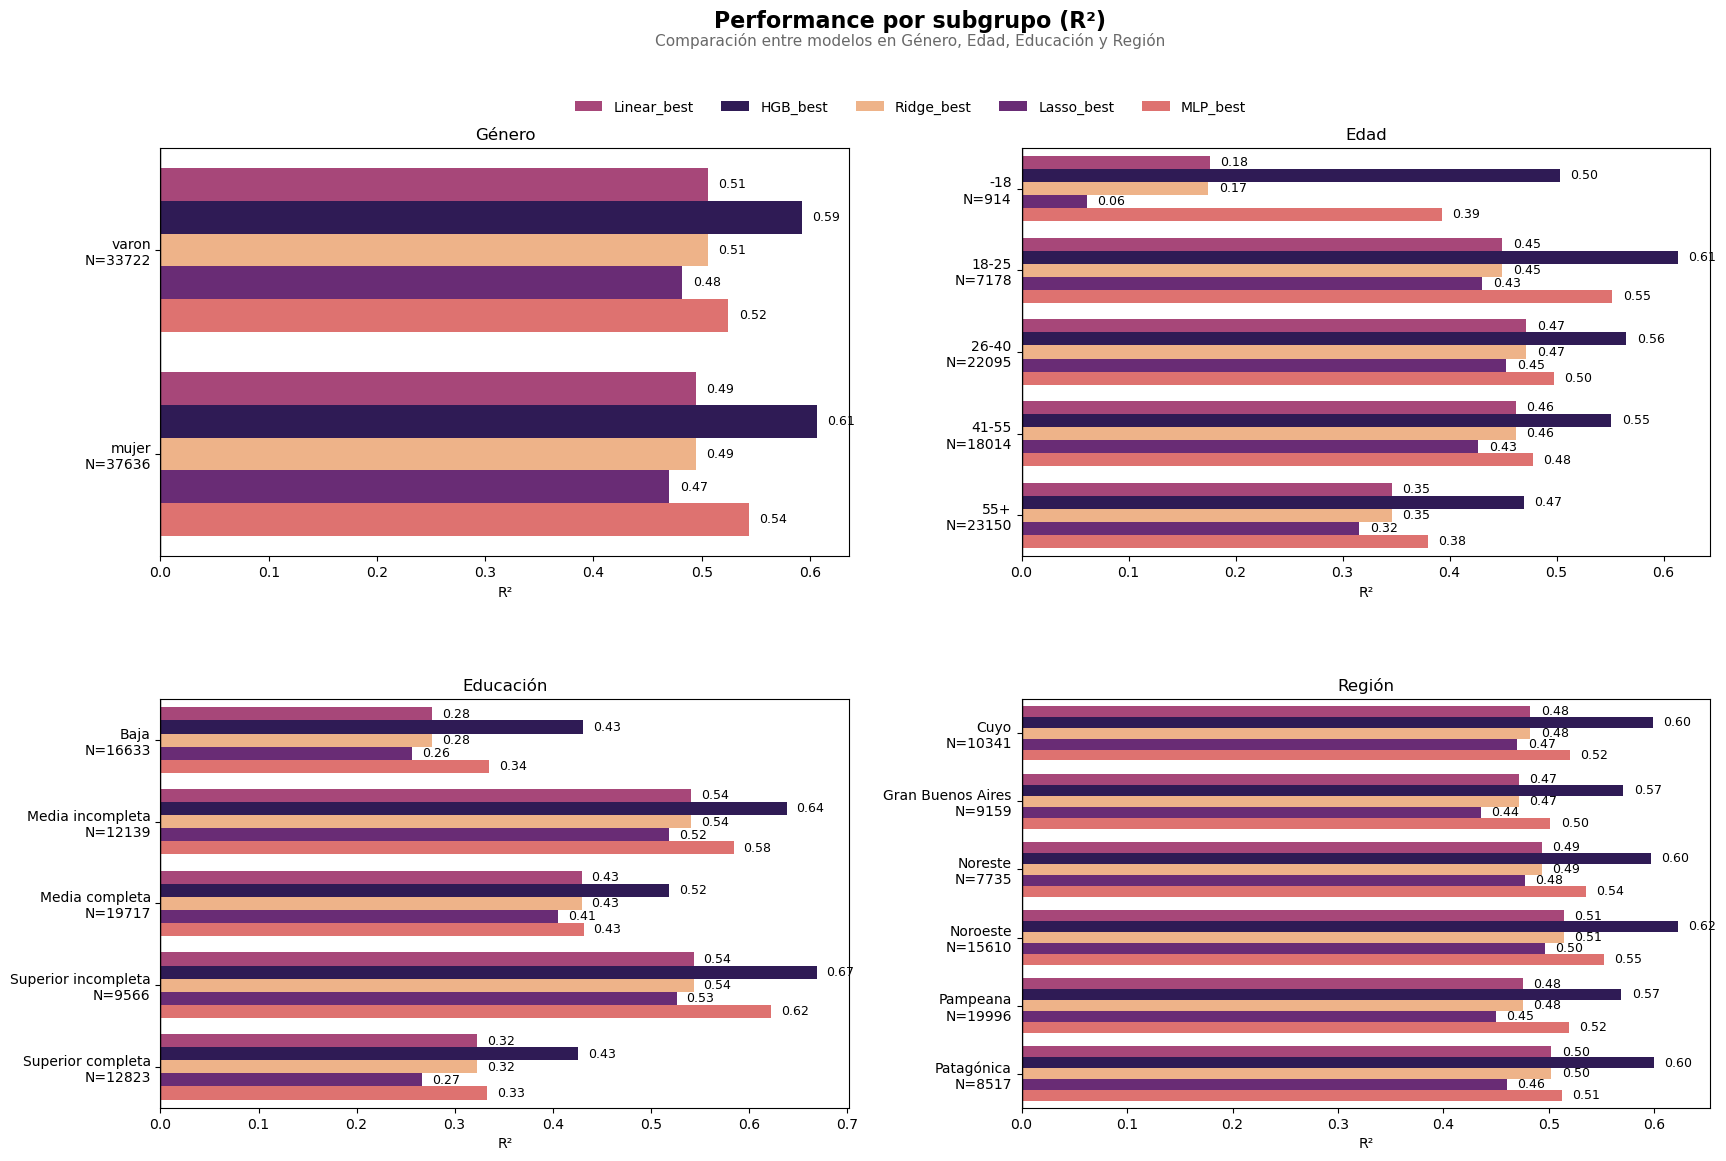

In [27]:
df_plot = df_subperf.dropna(subset=["dimension", "group", "model", "r2", "n","error","error_var","var_pred","var_real"]).copy()

models_names = sorted(df_plot["model"].unique())
palette_list = sns.color_palette("magma", n_colors=len(models_names)) 
palette = dict(zip(models_names, palette_list))

ncols = 2
nrows = 2

educ_order = [
    "Baja",
    "Media incompleta",
    "Media completa",
    "Superior incompleta",
    "Superior completa"
]

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(20, 6 * nrows),
    constrained_layout=False
)
axes = np.array(axes).reshape(-1)

legend_handles_labels = None
for i, dim in enumerate(df_plot["dimension"].unique()):
    ax = axes[i]
    d = df_plot[df_plot["dimension"] == dim].copy()

    if dim == "Educación":
        order_y = [g for g in educ_order]
    else:
        order_y = None

    sns.barplot(
        data=d,
        x="r2", y="group",
        hue="model",
        orient="h",
        palette=palette,
        ax=ax,
        order=order_y,
        errorbar=None
    )
    ax.set_title(dim)
    ax.set_xlabel("R²")
    ax.set_ylabel("")
    ax.axvline(0, color="black", linewidth=1)

    n_map = d.groupby("group")["n"].max().to_dict()
    current_labels = [t.get_text() for t in ax.get_yticklabels()]

    new_labels = []
    for g in current_labels:
        n_val = n_map.get(g, None)
        new_labels.append(f"{g}\nN={int(n_val)}")

    ax.set_yticklabels(new_labels)

    for p in ax.patches:
        width = p.get_width()
        if width >= 0.01:
            x = width
            y = p.get_y() + p.get_height() / 2
            ax.text(
                x + 0.01, y, f"{width:.2f}",
                va="center", ha="left",
                fontsize=9,
                color="black"
            )


    if legend_handles_labels is None:
        legend_handles_labels = ax.get_legend_handles_labels()

    ax.legend_.remove()


fig.suptitle(
    "Performance por subgrupo (R²)",
    fontsize=16, fontweight="bold", y=0.995
)

fig.text(
    0.5, 0.965,
    "Comparación entre modelos en Género, Edad, Educación y Región",
    ha="center", fontsize=11, color="dimgray"
)

fig.subplots_adjust(top=0.88, bottom=0.08, wspace=0.25, hspace=0.35)

handles, labels = legend_handles_labels
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=min(len(labels), 5),
    frameon=False,
    bbox_to_anchor=(0.5, 0.93) 
)

plt.savefig("subgroup_performance.png", dpi=300, bbox_inches="tight")
plt.show()

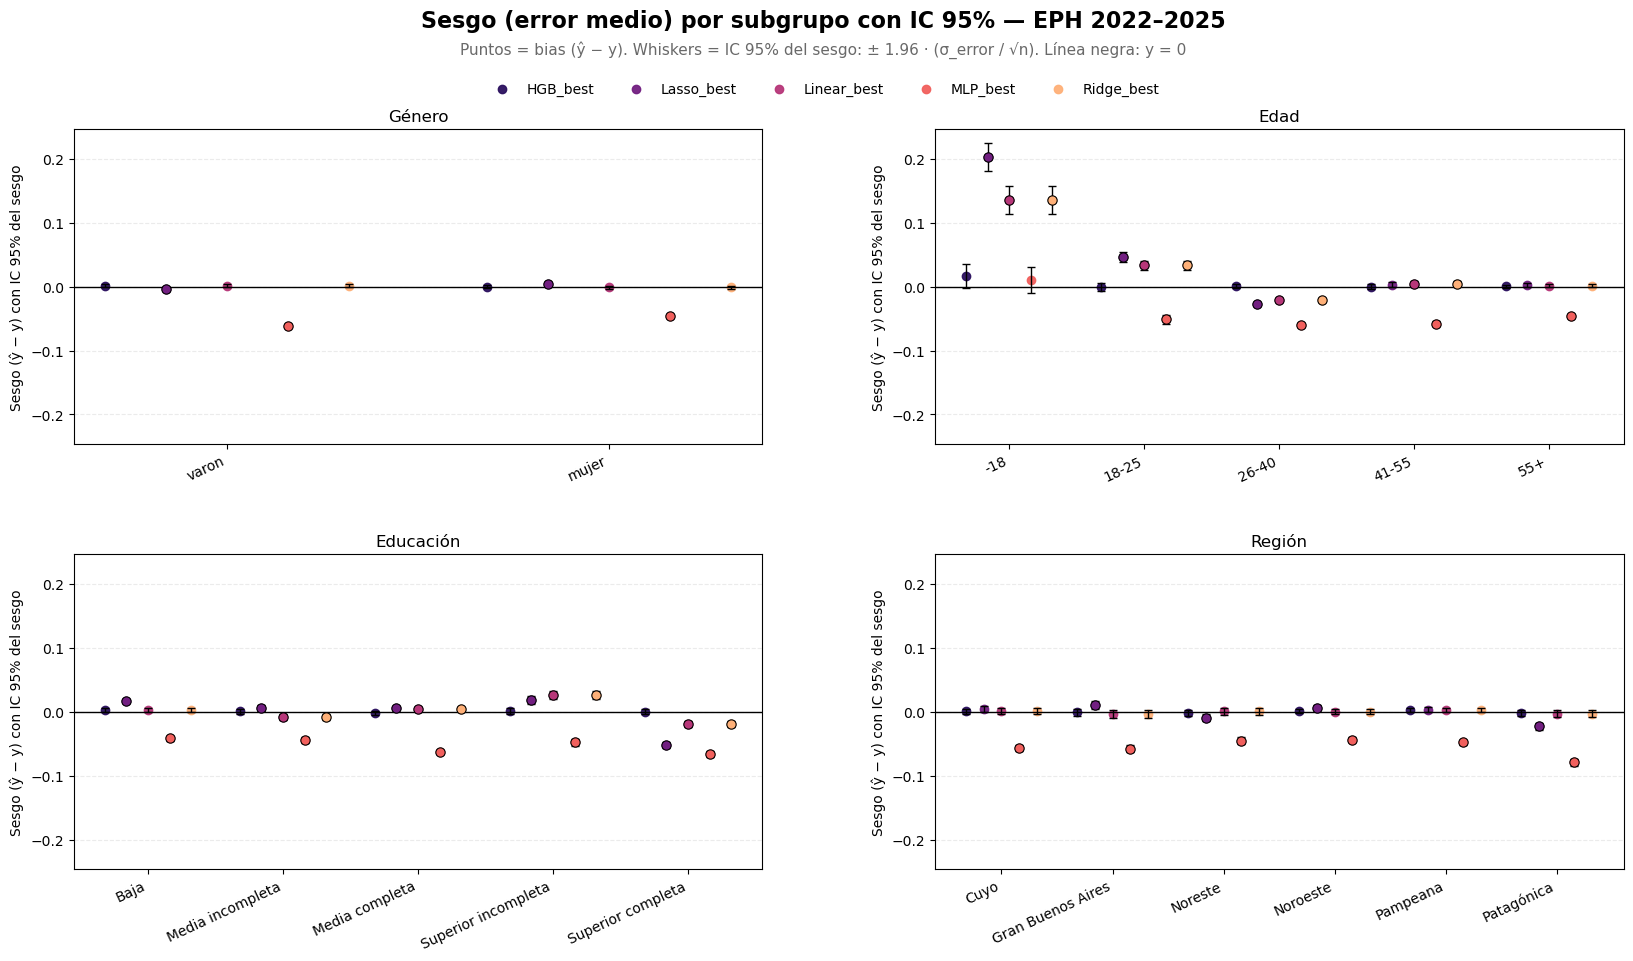

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10), constrained_layout=False)
axes = np.array(axes).reshape(-1)

panel_cache = []
global_max_abs = 0

for i, dim in enumerate(df_plot["dimension"].unique()):
    ax = axes[i]
    d = df_plot[df_plot["dimension"] == dim].copy()

    if dim == "Educación":
        groups = [g for g in educ_order]
    else:
        groups = d["group"].unique().tolist()

    x = np.arange(len(groups))
    m = len(models_names)
    width = 0.8 / max(m, 1)

    # Línea de referencia en y=0
    ax.axhline(0, color="black", linewidth=1)
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    max_abs = 0

    for j, model in enumerate(models_names):
        dm = d[d["model"] == model].set_index("group").reindex(groups)

        bias = dm["error"].to_numpy(dtype=float)

        # sigma
        sigma = np.sqrt(dm["error_var"].to_numpy(dtype=float))

        # tamaño del subgrupo
        n = dm["n"].to_numpy(dtype=float)

        # Error estándar del sesgo medio
        se = sigma / np.sqrt(n)

        # 95% CI (aprox): ± 1.96 * SE
        ci95 = 1.96 * se

        xpos = x - 0.4 + width/2 + j * width

        sig = ((bias - ci95 > 0) | (bias + ci95 < 0))

        # Puntos (bias)
        ax.scatter(
            xpos, bias,
            color=palette[model],
            label=model,
            alpha=0.95
        )

        ax.scatter(
            xpos[sig], bias[sig],
            color=palette[model],
            s=45,
            edgecolor="black",
            linewidth=0.8,
            zorder=4
        )

        # Errorbars = CI95 del sesgo
        ax.errorbar(
            xpos, bias,
            yerr=ci95,
            fmt="none",
            ecolor="black",
            elinewidth=1,
            capsize=3,
            capthick=1
        )

        valid = np.isfinite(bias) & np.isfinite(ci95)
        if valid.any():
            max_abs = max(max_abs, np.max(np.abs(bias[valid]) + ci95[valid]))

    global_max_abs = max(global_max_abs, max_abs)

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=25, ha="right")

    ax.set_title(dim)
    ax.set_xlabel("")
    ax.set_ylabel("Sesgo (ŷ − y) con IC 95% del sesgo")

    panel_cache.append(ax)

    for ax in panel_cache:
        ax.set_ylim(-1.1 * global_max_abs, 1.1 * global_max_abs)

    legend_handles_labels = ax.get_legend_handles_labels()

fig.suptitle(
    "Sesgo (error medio) por subgrupo con IC 95% — EPH 2022–2025",
    fontsize=16, fontweight="bold", y=0.98
)

fig.text(
    0.5, 0.935,
    "Puntos = bias (ŷ − y). Whiskers = IC 95% del sesgo: ± 1.96 · (σ_error / √n). Línea negra: y = 0",
    ha="center", fontsize=11, color="dimgray"
)

fig.subplots_adjust(top=0.86, bottom=0.12, wspace=0.25, hspace=0.35)

handles, labels = legend_handles_labels
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=min(len(labels), 6),
    frameon=False,
    bbox_to_anchor=(0.5, 0.92)
)

plt.savefig("Error Medio por Subgrupo - IC 95%")
plt.show()


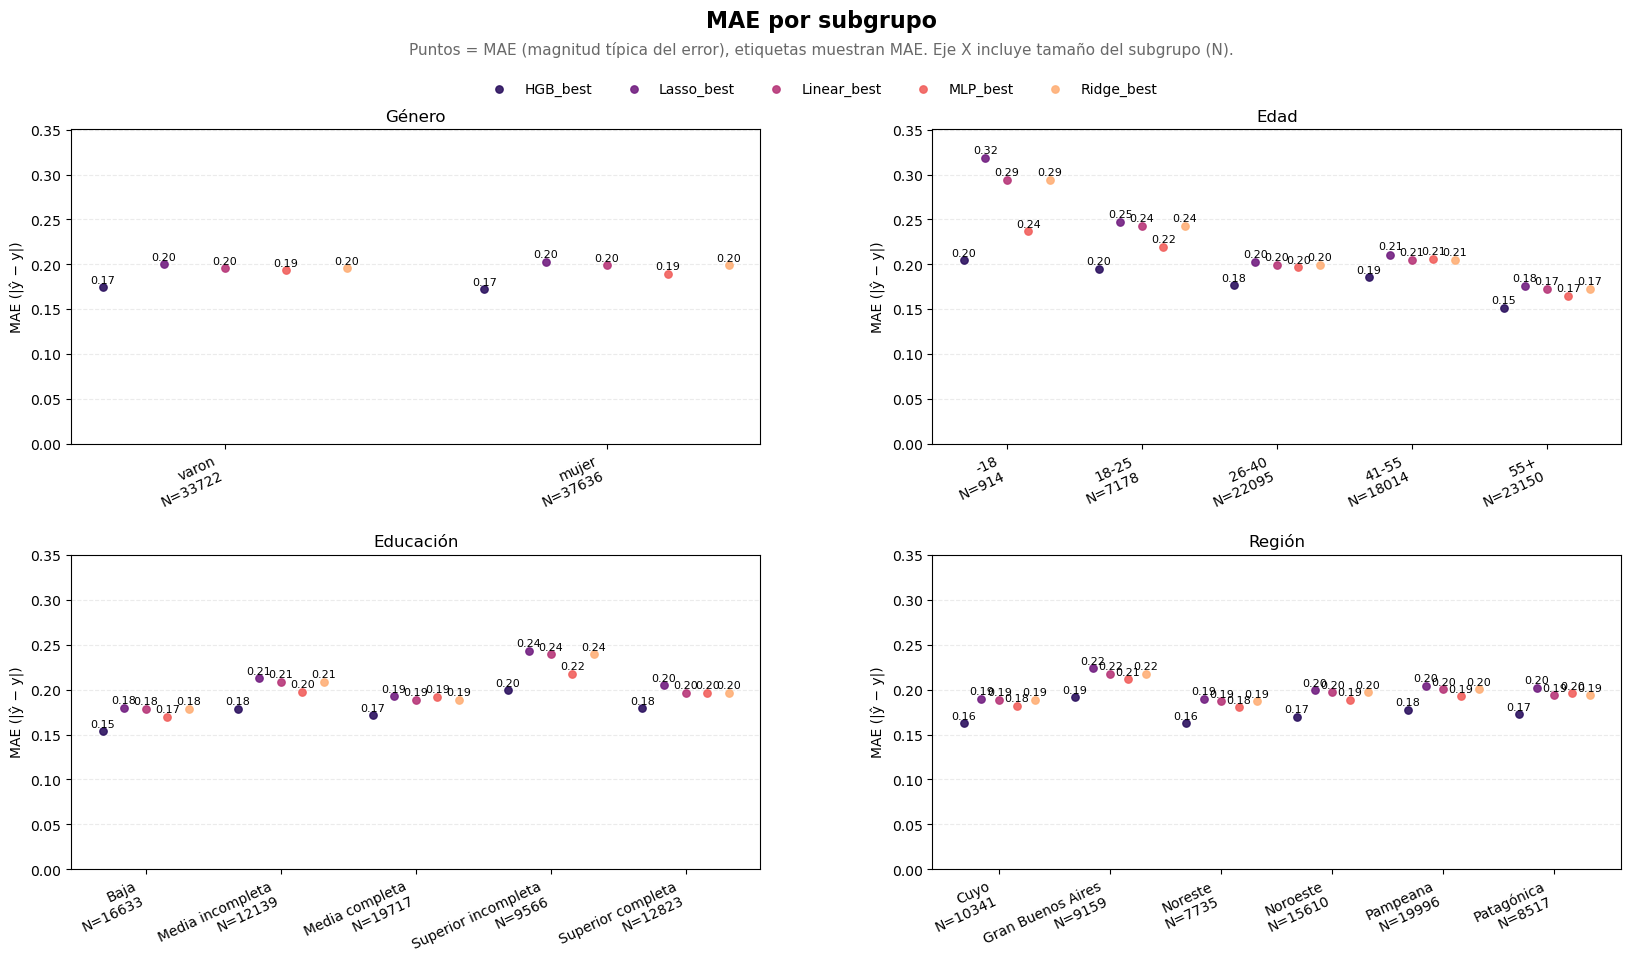

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10), constrained_layout=False)
axes = np.array(axes).reshape(-1)

legend_handles_labels = None
global_max = 0

for i, dim in enumerate(df_plot["dimension"].unique()):
    ax = axes[i]
    d = df_plot[df_plot["dimension"] == dim].copy()

    if dim == "Educación":
        groups = [g for g in educ_order]
    else:
        groups = d["group"].unique().tolist()

    n_map = d.groupby("group")["n"].max().to_dict()

    xlabels = [f"{g}\nN={int(n_map.get(g, 0))}" for g in groups]

    x = np.arange(len(groups))
    m = len(models_names)
    width = 0.8 / max(m, 1)

    ax.grid(axis="y", linestyle="--", alpha=0.25)

    local_max = 0

    for j, model in enumerate(models_names):
        dm = d[d["model"] == model].set_index("group").reindex(groups)

        mae = dm["mae"].to_numpy(dtype=float)

        xpos = x - 0.4 + width/2 + j * width

        # Puntos (MAE)
        ax.scatter(
            xpos, mae,
            color=palette[model],
            label=model,
            s=28,
            alpha=0.9,
            zorder=3
        )

        # Etiquetas numéricas sobre cada punto
        for xx, yy in zip(xpos, mae):
            if yy > 0:
                ax.text(
                    xx, yy + 0.01 * (np.nanmax(mae) if np.isfinite(np.nanmax(mae)) else 1),
                    f"{yy:.2f}",
                    ha="center", va="bottom",
                    fontsize=8,
                    color="black",
                    zorder=4
                )

        valid = np.isfinite(mae)
        if valid.any():
            local_max = max(local_max, np.max(mae[valid]))

    global_max = max(global_max, local_max)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=25, ha="right")

    ax.set_title(dim)
    ax.set_xlabel("")
    ax.set_ylabel("MAE (|ŷ − y|)")

    # Capturo leyenda global una sola vez
    if legend_handles_labels is None:
        legend_handles_labels = ax.get_legend_handles_labels()

# Unificar eje Y para comparar entre paneles
if global_max > 0:
    for ax in axes[:len(df_plot["dimension"].unique())]:
        ax.set_ylim(0, 1.10 * global_max)

fig.suptitle(
    "MAE por subgrupo",
    fontsize=16, fontweight="bold", y=0.98
)

fig.text(
    0.5, 0.935,
    "Puntos = MAE (magnitud típica del error), etiquetas muestran MAE. Eje X incluye tamaño del subgrupo (N).",
    ha="center", fontsize=11, color="dimgray"
)

fig.subplots_adjust(top=0.86, bottom=0.12, wspace=0.25, hspace=0.35)

handles, labels = legend_handles_labels
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=min(len(labels), 6),
    frameon=False,
    bbox_to_anchor=(0.5, 0.92)
)

plt.savefig("MAE por Subgrupo.png")
plt.show()

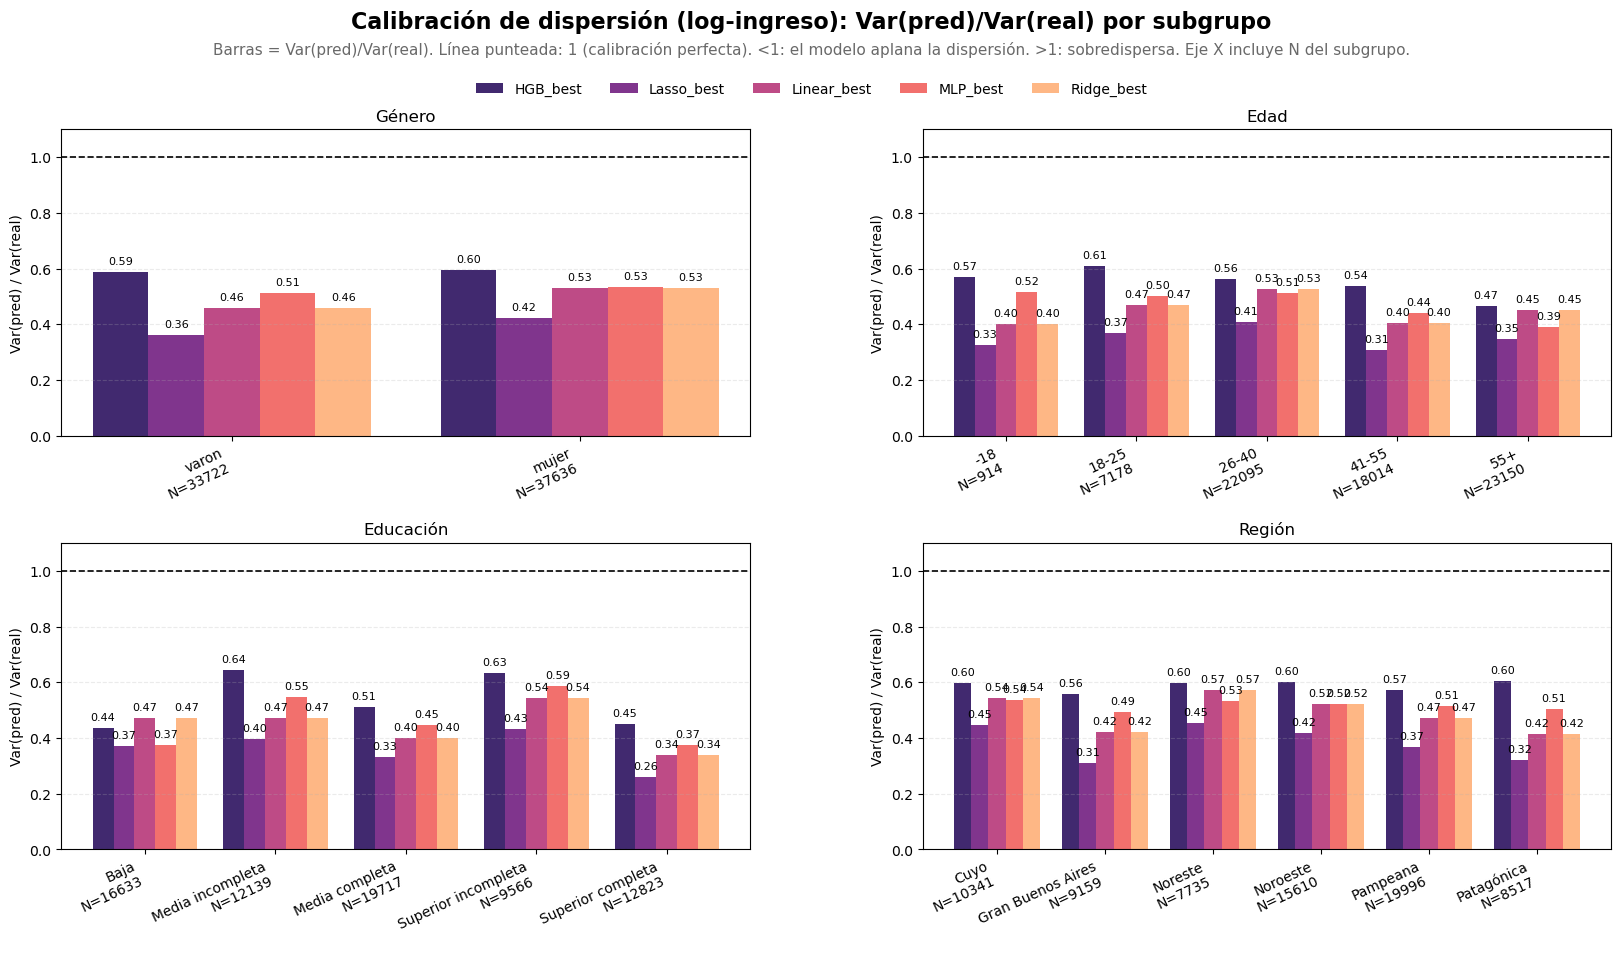

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10), constrained_layout=False)
axes = np.array(axes).reshape(-1)

legend_handles_labels = None
global_max = 1.0  # para incluir siempre la línea en 1

for i, dim in enumerate(df_plot["dimension"].unique()):
    ax = axes[i]
    d = df_plot[df_plot["dimension"] == dim].copy()

    if dim == "Educación":
        groups = [g for g in educ_order]
    else:
        groups = d["group"].unique().tolist()

    # N por grupo
    n_map = d.groupby("group")["n"].max().to_dict()

    # Labels en X con N debajo
    xlabels = [f"{g}\nN={int(n_map.get(g, 0))}" for g in groups]

    x = np.arange(len(groups))
    m = len(models_names)
    width = 0.8 / max(m, 1)

    # Línea de referencia
    ax.axhline(1.0, color="black", linewidth=1.2, linestyle="--")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    local_max = 1.0

    for j, model in enumerate(models_names):
        dm = d[d["model"] == model].set_index("group").reindex(groups)

        #quiero el ratio entre var_pred y var_real
        dm["var_ratio"] = dm["var_pred"] / dm["var_real"].replace(0, np.nan)

        ratio = dm["var_ratio"].to_numpy(dtype=float)

        xpos = x - 0.4 + width/2 + j * width

        bars = ax.bar(
            xpos, ratio,
            width=width,
            color=palette[model],
            alpha=0.9,
            label=model
        )

        for rect, val in zip(bars, ratio):
            if np.isfinite(val):
                if val >= 0.01:
                    ax.text(
                        rect.get_x() + rect.get_width()/2,
                        rect.get_height() + 0.02,   # desplazamiento vertical
                        f"{val:.2f}",
                        ha="center", va="bottom",
                        fontsize=8,
                        color="black",
                        zorder=5
                    )

        valid = np.isfinite(ratio)
        if valid.any():
            local_max = max(local_max, float(np.nanmax(ratio[valid])))

    global_max = max(global_max, local_max)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=25, ha="right")

    ax.set_title(dim)
    ax.set_ylabel("Var(pred) / Var(real)")

# Unificar límites
for ax in axes[:len(df_plot["dimension"].unique())]:
    ax.set_ylim(0, 1.10 * global_max)

fig.suptitle(
    "Calibración de dispersión (log‑ingreso): Var(pred)/Var(real) por subgrupo",
    fontsize=16, fontweight="bold", y=0.98
)

fig.text(
    0.5, 0.935,
    "Barras = Var(pred)/Var(real). Línea punteada: 1 (calibración perfecta). "
    "<1: el modelo aplana la dispersión. >1: sobredispersa. Eje X incluye N del subgrupo.",
    ha="center", fontsize=11, color="dimgray"
)

fig.subplots_adjust(top=0.86, bottom=0.14, wspace=0.25, hspace=0.35)

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=min(len(labels), 6),
    frameon=False,
    bbox_to_anchor=(0.5, 0.92)
)
plt.savefig("Var_Ratio_by_Subgroup.png")
plt.show()


In [31]:
#Permutation Importance
def mixed_permutation_importance(
    estimator,
    X_test: pd.DataFrame,
    y_test,
    groups: dict,
    n_repeats: int = 20,
    random_state: int = 42,
    scoring="r2"
):

    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_test).astype(float)

    # Baselines
    y_pred_base = estimator.predict(X_test)
    base_r2  = r2_score(y_true, y_pred_base)
    base_mae = mean_absolute_error(y_true, y_pred_base)

    n = len(X_test)
    rows = []

    # Normalizar bloques
    clean_groups = {}
    blocked_cols = set()
    for gname, cols in groups.items():
        cols_ok = [c for c in cols if c in X_test.columns]
        if len(cols_ok) == 0:
            continue
        clean_groups[gname] = cols_ok
        blocked_cols.update(cols_ok)

    # 2) Armar lista de "targets" a permutar: (nombre, lista_de_columnas)
    targets = []

    # primero bloques
    for gname, cols in clean_groups.items():
        targets.append((gname, cols))

    # luego columnas sueltas (las que no estén ya en un bloque)
    for col in X_test.columns:
        if col not in blocked_cols:
            targets.append((col, [col]))

    # 3) Permutar y medir caída de score
    for name, cols in targets:
        print("Columna:", name)
        drops_r2  = []
        drops_mae = []
        for _ in range(n_repeats):
            perm = rng.permutation(n)
            Xp = X_test.copy()
            # Permutar filas de las columnas objetivo
            Xp.loc[:, cols] = Xp.loc[:, cols].to_numpy()[perm, :]

            y_pred_perm = estimator.predict(Xp)
            r2_perm  = r2_score(y_true, y_pred_perm)
            mae_perm = mean_absolute_error(y_true, y_pred_perm)

            drops_r2.append(base_r2 - r2_perm)       # performance (caída de R2)
            drops_mae.append(mae_perm - base_mae)    # aumento de MAE

        rows.append({
            "feature_or_group": name,
            "n_cols": len(cols),

            # R²-based importance (nombres compatibles con el resto del notebook)
            "base_score": base_r2,
            "importance_mean": np.mean(drops_r2),
            "importance_std":  np.std(drops_r2, ddof=1),

            # MAE-based additional info
            "base_mae": base_mae,
            "imp_mae_mean": np.mean(drops_mae),
            "imp_mae_std":  np.std(drops_mae, ddof=1),
        })

    # ordenar por importancia (R²)
    return pd.DataFrame(rows).sort_values("importance_mean", ascending=False)

In [32]:
X_train = DGS.X_train
y_train = DGS.y_train
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [34]:
#Veo comportamiento deterministico entre variables tanto numericas como categoricas, en funcion a eso armo grupos para Permutation Importance
def deterministic_score(A: pd.Series, B: pd.Series):
    """
    Mide qué tan determinístico es B dado A y A dado B.
    Devuelve:
      - pmax_B_given_A: promedio ponderado del max P(B|A=a)
      - pmax_A_given_B: promedio ponderado del max P(A|B=b)
    Valores cerca de 1 => casi determinismo.
    """
    tab = pd.crosstab(A, B, dropna=False)
    # P(B|A)
    p_B_given_A = tab.div(tab.sum(axis=1), axis=0)
    max_B_given_A = p_B_given_A.max(axis=1)
    weights_A = tab.sum(axis=1) / tab.values.sum()
    pmax_B_given_A = float((max_B_given_A * weights_A).sum())

    # P(A|B)
    p_A_given_B = tab.div(tab.sum(axis=0), axis=1)
    max_A_given_B = p_A_given_B.max(axis=0)
    weights_B = tab.sum(axis=0) / tab.values.sum()
    pmax_A_given_B = float((max_A_given_B * weights_B).sum())

    return pmax_B_given_A, pmax_A_given_B

def find_near_deterministic_pairs(X: pd.DataFrame, cat_cols, threshold=0.98, max_pairs=200):
    """
    Busca pares (A,B) donde B está casi determinado por A o viceversa.
    threshold típico: 0.98 o 0.99.
    """
    pairs = []
    cols = list(cat_cols)
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            A, B = cols[i], cols[j]
            p1, p2 = deterministic_score(X[A], X[B])
            if (p1 >= threshold) or (p2 >= threshold):
                pairs.append((A, B, p1, p2))
                if len(pairs) >= max_pairs:
                    return pd.DataFrame(pairs, columns=["A","B","pmax_B|A","pmax_A|B"]).sort_values(
                        ["pmax_B|A","pmax_A|B"], ascending=False
                    )
    return pd.DataFrame(pairs, columns=["A","B","pmax_B|A","pmax_A|B"]).sort_values(
        ["pmax_B|A","pmax_A|B"], ascending=False
    )


det_pairs = find_near_deterministic_pairs(X_train, cat_cols, threshold=0.98)
print(det_pairs)

num_corr = X_train[num_cols].corr(method="spearman").abs()
strong_num = (num_corr.where(np.triu(np.ones(num_corr.shape), 1).astype(bool))
                      .stack()
                      .sort_values(ascending=False))
strong_num_df = pd.DataFrame(strong_num).reset_index()
strong_num_df.columns = ["Variable 1", "Variable 2", "Correlation"]
strong_num_df.to_csv("strong_numerical_correlations.csv", index=False)

          A        B  pmax_B|A  pmax_A|B
0  CAT_INAC  CONDACT  0.981017  0.881731
1  CAT_OCUP  CONDACT  0.980609  0.836354


In [35]:
ESTRUCTURA_LABORAL = [
    "CONDACT",
    "CAT_OCUP",
    "CAT_INAC"
]
EDUCACION = [
    "P09", 
    "P10"  
]
VIVIENDA_HOGAR = [
    "H05", "H06",
    "H07", "H08", "H09","sanitacion_nivel"
    , "H13", "H14"
]
CALIDAD_LABORAL = [
    "PP07G_59"
]
AÑO = [c for c in X_test.columns if c.startswith("ANIO_") and c.endswith("_Dummy")]
TRIMESTRE = [c for c in X_test.columns if c.startswith("TRIMESTRE_") and c.endswith("_Dummy")]

#Permutation Importance
groups = {
    "ESTRUCTURA_LABORAL": ESTRUCTURA_LABORAL,
    "VIVIENDA_HOGAR": VIVIENDA_HOGAR,
    "EDUCACION": EDUCACION,
    "CALIDAD_LABORAL": CALIDAD_LABORAL,
    "AÑO": AÑO,
    "TRIMESTRE": TRIMESTRE
}

X_test_perm = DGS.X_test.copy().drop(["age_group","educ_group"], axis=1)

In [36]:
imp_all = []
for model_name, est in models.items():
    print("Evaluando: ", model_name)
    imp = mixed_permutation_importance(
        estimator=est,
        X_test=X_test_perm,
        y_test=y_test,
        groups=groups,
        n_repeats=30,
        random_state=42
    )
    imp["model"] = model_name
    imp_all.append(imp)

imp_all_df = pd.concat(imp_all, ignore_index=True)


Evaluando:  Linear_best
Columna: ESTRUCTURA_LABORAL
Columna: VIVIENDA_HOGAR
Columna: EDUCACION
Columna: CALIDAD_LABORAL
Columna: ANO4
Columna: TRIMESTRE
Columna: AGLOMERADO
Columna: V01
Columna: H16
Columna: H15
Columna: PROP
Columna: IX_TOT
Columna: P02
Columna: P03
Columna: CH07
Columna: P05
Columna: Region
Columna: AGLO_rk
Columna: Reg_rk
Columna: Personas_0-3
Columna: Personas_13-17
Columna: Personas_18-24
Columna: Personas_25-64
Columna: Personas_4-8
Columna: Personas_65+
Columna: Personas_9-12
Columna: Max_Nivel_Educativo
Evaluando:  HGB_best
Columna: ESTRUCTURA_LABORAL
Columna: VIVIENDA_HOGAR
Columna: EDUCACION
Columna: CALIDAD_LABORAL
Columna: ANO4
Columna: TRIMESTRE
Columna: AGLOMERADO
Columna: V01
Columna: H16
Columna: H15
Columna: PROP
Columna: IX_TOT
Columna: P02
Columna: P03
Columna: CH07
Columna: P05
Columna: Region
Columna: AGLO_rk
Columna: Reg_rk
Columna: Personas_0-3
Columna: Personas_13-17
Columna: Personas_18-24
Columna: Personas_25-64
Columna: Personas_4-8
Columna: 

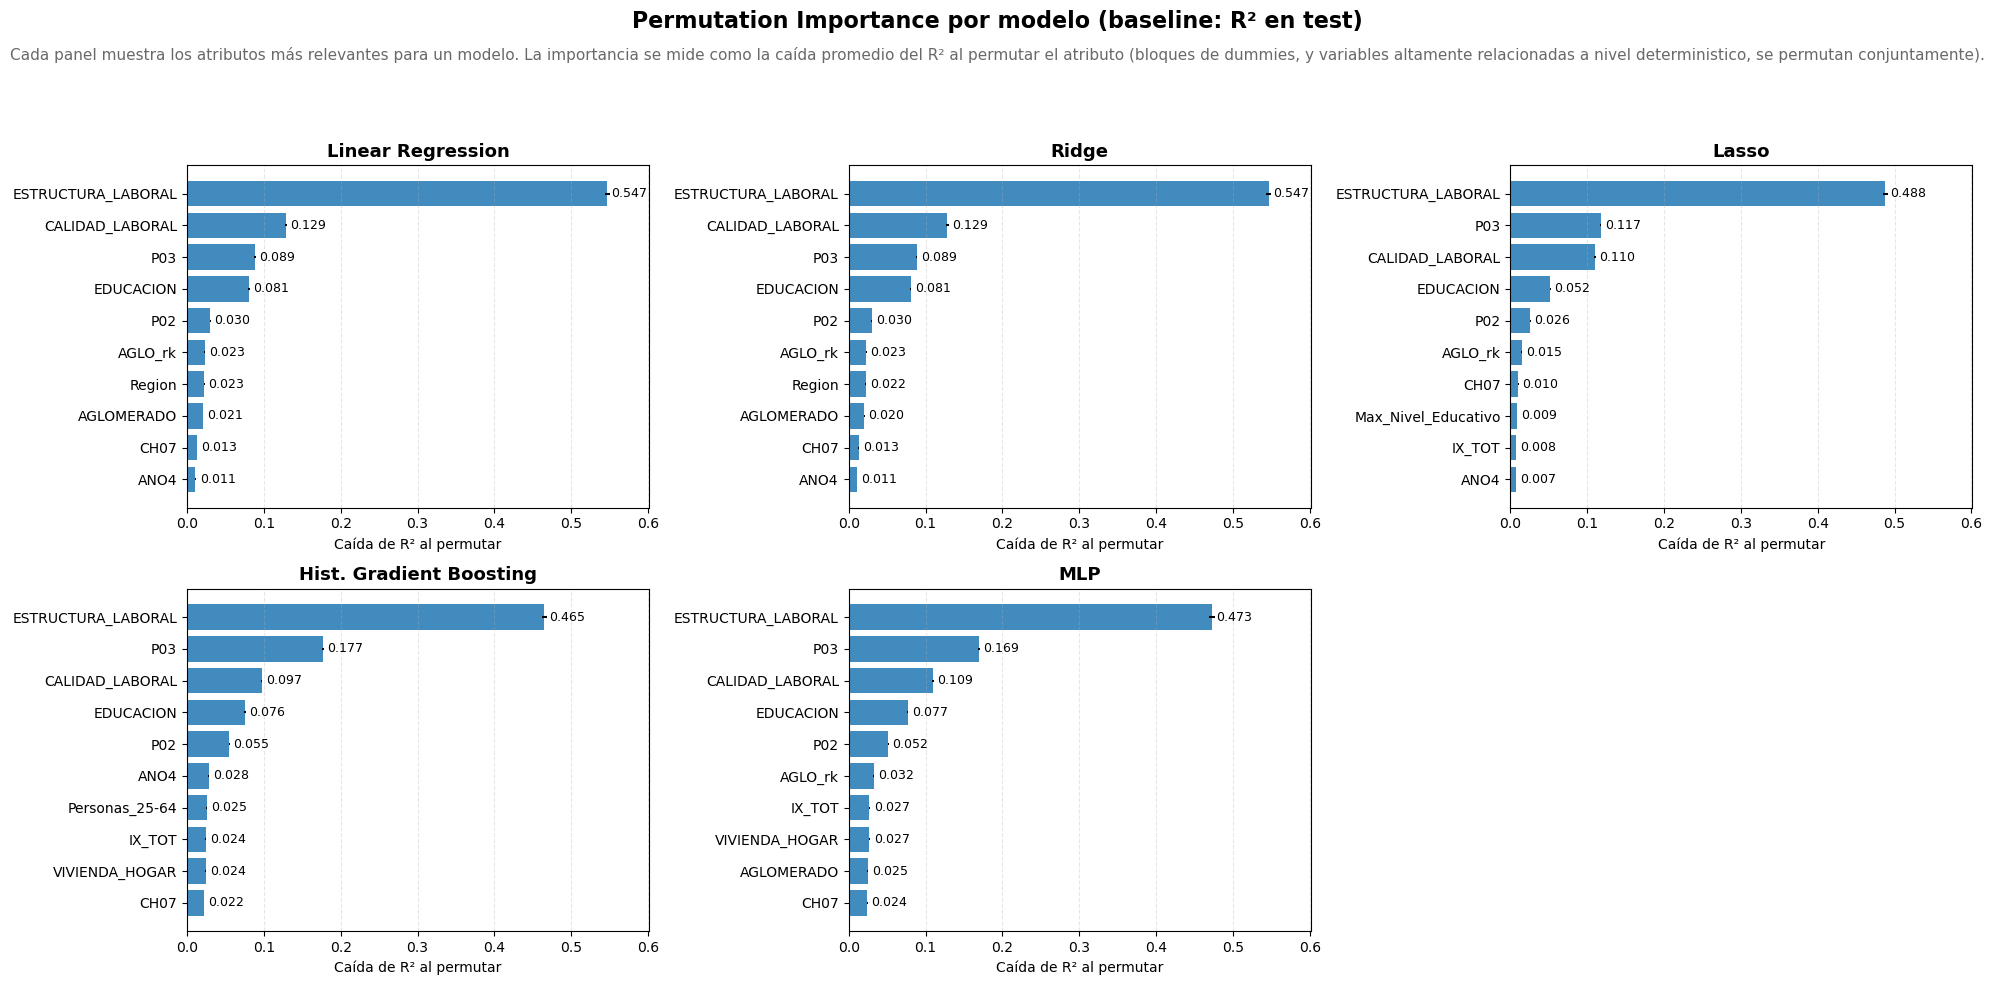

In [37]:
imp_all_df.to_csv("permutation_importance.csv", index=False)

MODELS_ORDER = [
    "Linear_best",
    "Ridge_best",
    "Lasso_best",
    "HGB_best",
    "MLP_best"
]


MODEL_TITLES = {
    "Linear_best": "Linear Regression",
    "Ridge_best": "Ridge",
    "Lasso_best": "Lasso",
    "HGB_best": "Hist. Gradient Boosting",
    "MLP_best": "MLP"
}

TOP_K = 10   #variables a mostrar por modelo

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

#Escalo ejes X
global_max = imp_all_df["importance_mean"].max()

# Loop por modelo
for i, model in enumerate(MODELS_ORDER):
    ax = axes[i]

    d = (imp_all_df[imp_all_df["model"] == model]
         .sort_values("importance_mean", ascending=False)
         .head(TOP_K)
         .iloc[::-1])   # invertir para que el más importante quede arriba

    bars = ax.barh(
        d["feature_or_group"],
        d["importance_mean"],
        xerr=d["importance_std"],
        color="tab:blue",
        alpha=0.85
    )

    for bar, mean in zip(bars, d["importance_mean"]):
        y = bar.get_y() + bar.get_height() / 2
        x = bar.get_width()
        ax.text(
            x + 0.01 * global_max,
            y,
            f"{mean:.3f}",
            va="center",
            ha="left",
            fontsize=9,
            color="black"
        )

    ax.set_title(MODEL_TITLES[model], fontsize=13, fontweight="bold")
    ax.set_xlabel("Caída de R² al permutar")
    ax.set_xlim(0, 1.1 * global_max)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

axes[-1].axis("off")

fig.suptitle(
    "Permutation Importance por modelo (baseline: R² en test)",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5, 0.93,
    "Cada panel muestra los atributos más relevantes para un modelo. "
    "La importancia se mide como la caída promedio del R² al permutar el atributo "
    "(bloques de dummies, y variables altamente relacionadas a nivel deterministico, se permutan conjuntamente).",
    ha="center",
    fontsize=11,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("permutation_importance_by_model_R2.png", dpi=300)
plt.show()

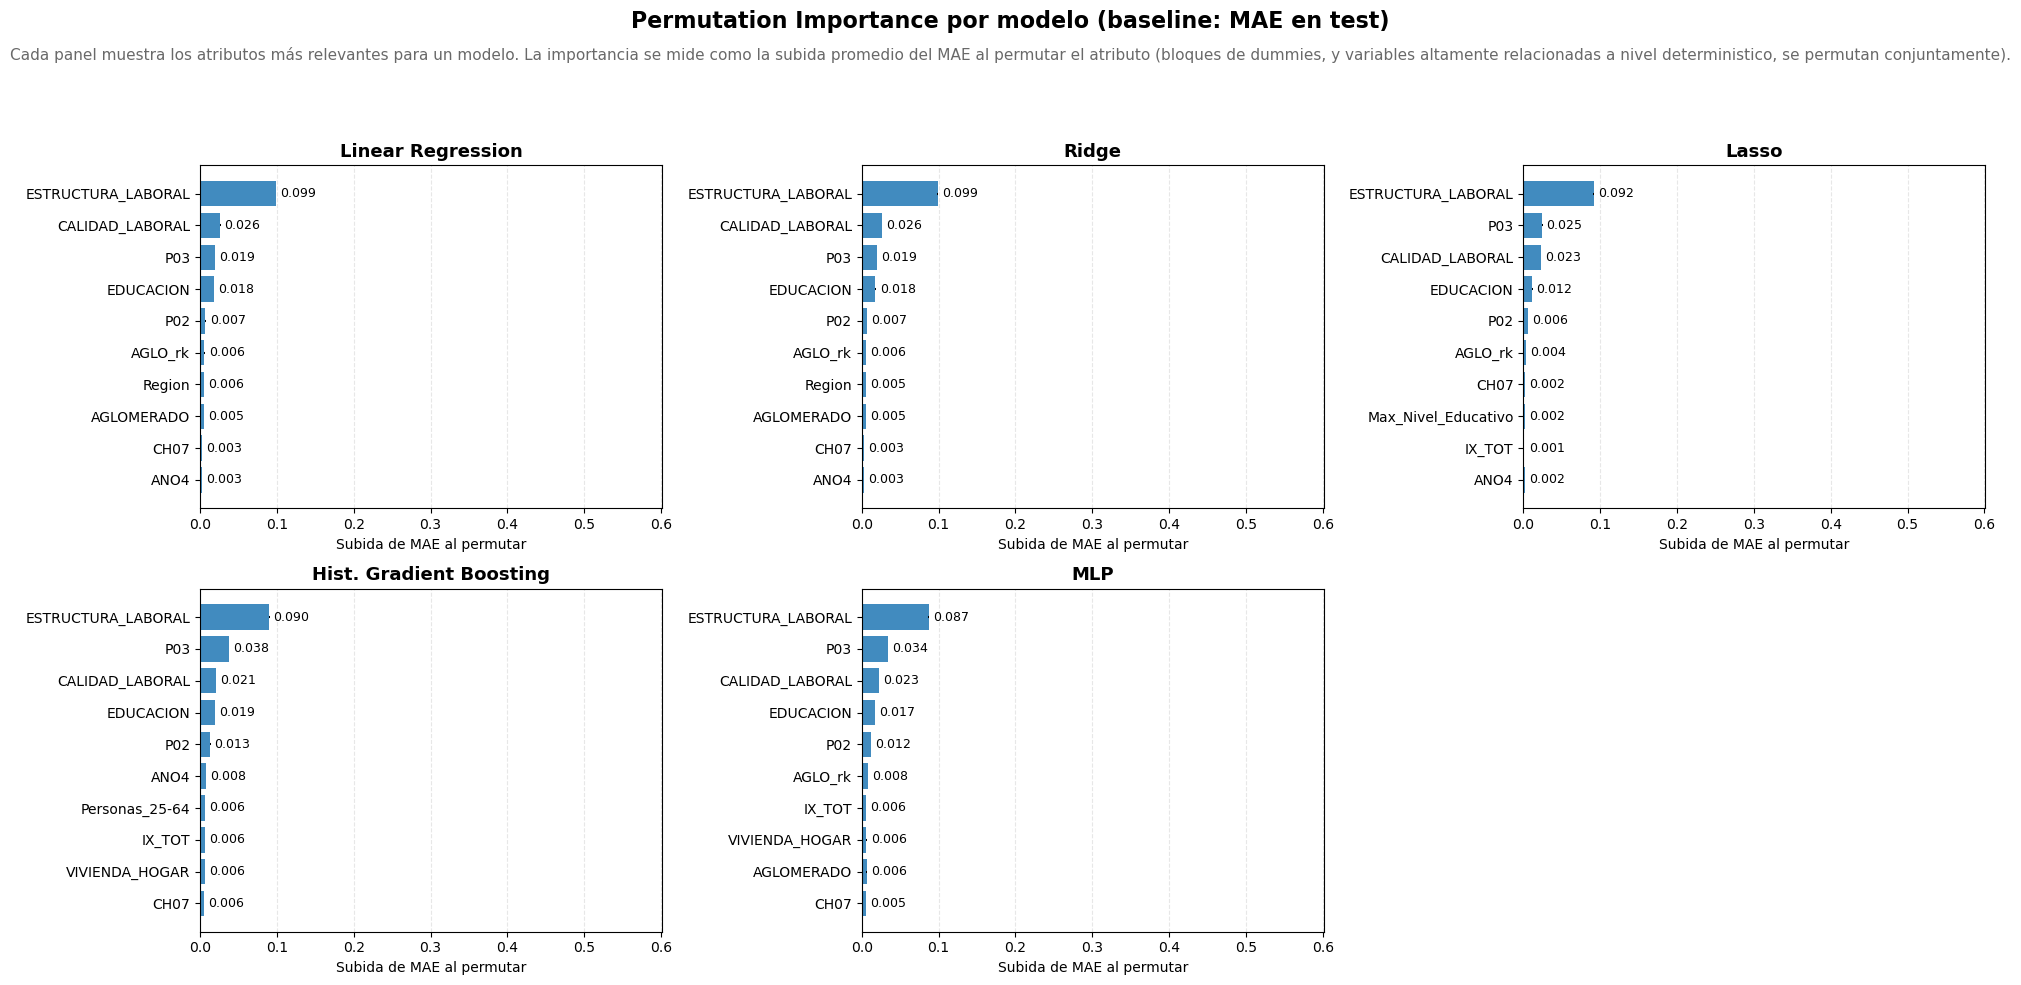

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

#Escalo ejes X
global_max = imp_all_df["importance_mean"].max()

# Loop por modelo
for i, model in enumerate(MODELS_ORDER):
    ax = axes[i]

    d = (imp_all_df[imp_all_df["model"] == model]
         .sort_values("importance_mean", ascending=False)
         .head(TOP_K)
         .iloc[::-1])   # invertir para que el más importante quede arriba

    bars = ax.barh(
        d["feature_or_group"],
        d["imp_mae_mean"],
        xerr=d["imp_mae_std"],
        color="tab:blue",
        alpha=0.85
    )

    for bar, mean in zip(bars, d["imp_mae_mean"]):
        y = bar.get_y() + bar.get_height() / 2
        x = bar.get_width()
        ax.text(
            x + 0.01 * global_max,
            y,
            f"{mean:.3f}",
            va="center",
            ha="left",
            fontsize=9,
            color="black"
        )

    ax.set_title(MODEL_TITLES[model], fontsize=13, fontweight="bold")
    ax.set_xlabel("Subida de MAE al permutar")
    ax.set_xlim(0, 1.1 * global_max)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

axes[-1].axis("off")

fig.suptitle(
    "Permutation Importance por modelo (baseline: MAE en test)",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5, 0.93,
    "Cada panel muestra los atributos más relevantes para un modelo. "
    "La importancia se mide como la subida promedio del MAE al permutar el atributo "
    "(bloques de dummies, y variables altamente relacionadas a nivel deterministico, se permutan conjuntamente).",
    ha="center",
    fontsize=11,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("permutation_importance_by_model_MAE.png", dpi=300)
plt.show()

In [39]:
def coef_df_from_best(best_pipe, model_name, preproc_step="preproc", reg_step="reg"):
    
    # 1) Tomo el preprocesador desde el pipeline
    pre = best_pipe.named_steps[preproc_step]
    
    # 2) Tomo el modelo desde el pipeline
    reg = best_pipe.named_steps[reg_step]

    # 3) Pido los nombres finales de las features luego de:
    #    - StandardScaler para numéricas
    #    - OneHotEncoder para categóricas
    #    - y el armado del ColumnTransformer
    feature_names = pre.get_feature_names_out()

    # 4) Obtengo el vector de coeficientes del modelo entrenado
    coefs = np.round(reg.coef_, 4)

    # 5) Armo el DataFrame con nombres y coeficientes, usando 'model_name' como nombre de columna
    return pd.DataFrame({
        "feature": feature_names,
        model_name: coefs
    })


In [40]:
df_lr    = coef_df_from_best(best_lr, "LR")
df_ridge = coef_df_from_best(best_ridge, "Ridge")
df_lasso = coef_df_from_best(best_lasso, "Lasso")
df_coefs = df_lr.merge(df_ridge, on="feature").merge(df_lasso, on="feature")
df_coefs.to_csv("model_coefficients.csv", index=False)

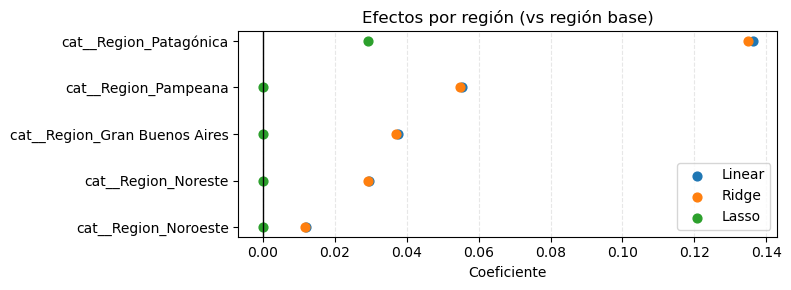

In [44]:
def forest_plot_3models(df, features, title, xlabel="Coeficiente"):
    d = df[df["feature"].isin(features)].copy()

    # ordenar por Ridge
    d["abs"] = d["Ridge"].abs()
    d = d.sort_values("abs", ascending=False).drop(columns="abs")
    d = d.iloc[::-1].reset_index(drop=True)

    y = np.arange(len(d))

    plt.figure(figsize=(8, max(3, 0.4*len(d))))
    plt.axvline(0, color="black", lw=1)

    plt.scatter(d["LR"], y, label="Linear", s=40)
    plt.scatter(d["Ridge"], y, label="Ridge", s=40)
    plt.scatter(d["Lasso"], y, label="Lasso", s=40)

    plt.yticks(y, d["feature"])
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


region_feats = df_coefs[df_coefs["feature"].str.startswith("cat__Region_")]["feature"].tolist()

forest_plot_3models(
    df_coefs,
    region_feats,
    title="Efectos por región (vs región base)"
)



In [103]:
def coef_to_pct_log10(beta):
    """
    Convierte un coeficiente beta en log10(ingreso) a % exacto.
    Si y = log10(ingreso), entonces el factor multiplicativo es 10**beta,
    y el cambio porcentual es 100*(10**beta - 1).
    """
    return 100.0 * (np.power(10.0, beta) - 1.0)


def plot_coef_blocks_2x3(
    coef_df: pd.DataFrame,
    blocks: list,
    model_cols=("LR", "Ridge", "Lasso"),
    top_k=12,
    use_percent=False,
    sort_by="Ridge",
    figsize=(22, 12),
    suptitle="Coeficientes por bloque (LR / Ridge / Lasso)",
):
    """
    Grafica coeficientes (o % equivalente) para varios bloques en una grilla 2x3.

    Parameters
    ----------
    coef_df : pd.DataFrame
        DataFrame con columnas: 'feature' y una columna por modelo en model_cols
        (ej: 'LR', 'Ridge', 'Lasso').

    blocks : list of dict
        Cada dict define un subplot/bloque:
          - 'title': str  (título del subplot)
          - 'prefix': str (prefijo de features, ej 'cat__Region_')
          - 'base_note': str opcional (texto de base, se muestra bajo el título)
          - 'top_k': int opcional (sobrescribe top_k global para ese bloque)

    model_cols : tuple
        Columnas del DataFrame que representan modelos a comparar.

    top_k : int
        Máximo de categorías por bloque (si hay muchas, toma las top por |sort_by|).

    use_percent : bool
        Si True, convierte coeficientes a % exacto asumiendo y=log10(ingreso).

    sort_by : str
        Columna (modelo) usada para ordenar por magnitud absoluta.

    figsize : tuple
        Tamaño de la figura.

    suptitle : str
        Título general.

    Notes
    -----
    - Este gráfico es ideal para dummies (categorías vs base).
    - Si use_percent=True, el eje X es % cambio (exacto) vs base.
    - Labels Y se muestran sin el prefix para mayor legibilidad.
    """

    df = coef_df.copy()

    # Convertir a % si corresponde (log10)
    if use_percent:
        for c in model_cols:
            df[c] = coef_to_pct_log10(df[c].astype(float))

    # Colores fijos por modelo (si agregás otro modelo, asigna gris por default)
    default_colors = {
        "LR": "#1f77b4",     # azul
        "Ridge": "#ff7f0e",  # naranja
        "Lasso": "#2ca02c",  # verde
    }

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    legend_handles = None
    legend_labels = None

    for i, blk in enumerate(blocks):
        ax = axes[i]
        prefix = blk["prefix"]
        title = blk["title"]
        base_note = blk.get("base_note", "")
        k = blk.get("top_k", top_k)
        order = blk.get("order", None)

        d = df[df["feature"].str.startswith(prefix)].copy()

        # Ordenar por magnitud del modelo sort_by
        d["abs_sort"] = d[sort_by].abs()
        d = d.sort_values("abs_sort", ascending=False).drop(columns="abs_sort")

        # Recortar top_k si aplica
        if k is not None and len(d) > k:
            d = d.head(k)

        d["label"] = d["feature"].str.replace(prefix, "", regex=False).astype(str)

        if order is not None:
            # Convierto a categórica ordenada para que sort_values respete orden
            cat_type = pd.CategoricalDtype(categories=order, ordered=True)
            d["label"] = d["label"].astype(cat_type)
            d = d.sort_values("label", ascending=True)
            # Para que el más alto quede arriba, invertimos
            d = d.iloc[::-1].reset_index(drop=True)
        else:
            # Si no hay orden, mantenemos el orden por magnitud y luego invertimos
            d = d.iloc[::-1].reset_index(drop=True)


        y = np.arange(len(d))

        # Línea vertical en 0 (sin efecto)
        ax.axvline(0, color="black", linewidth=1, alpha=0.7)

        # Puntos por modelo con offsets para evitar solapamiento
        offsets = np.linspace(-0.18, 0.18, num=len(model_cols))
        for j, c in enumerate(model_cols):
            ax.scatter(
                d[c].values,
                y + offsets[j],
                s=35,
                color=default_colors.get(c, "gray"),
                label=c,
                alpha=0.9
            )

        # Labels Y sin prefijo
        short_labels = d["feature"].str.replace(prefix, "", regex=False)
        ax.set_yticks(y)
        ax.set_yticklabels(short_labels)

        # Título y nota de base
        if base_note:
            ax.set_title(f"{title}\nBase: {base_note}", fontsize=12, fontweight="bold")
        else:
            ax.set_title(title, fontsize=12, fontweight="bold")

        ax.set_xlabel("% cambio ingreso (log10)" if use_percent else "Coeficiente (log10 ingreso)")
        ax.grid(axis="x", linestyle="--", alpha=0.25)

        # Guardar leyenda del primer subplot
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        # Quitar leyenda por subplot (usamos global)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Apagar subplots sobrantes si blocks < 6
    for j in range(len(blocks), 6):
        axes[j].axis("off")

    # Leyenda global
    if legend_handles is not None:
        fig.legend(
            legend_handles, legend_labels,
            loc="upper center",
            ncol=min(5, len(model_cols)),
            frameon=False,
            bbox_to_anchor=(0.5, 0.98)
        )

    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("coef_blocks_comparison.png", dpi=300)
    plt.show()


In [99]:
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P02_2", "cat__P02_Mujer")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__CONDACT_2", "cat__CONDACT_Desocupado")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__CONDACT_3", "cat__CONDACT_Inactivo")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__CONDACT_9", "cat__CONDACT_Otro/Nulo")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__PP07G_59_5.0", "cat__PP07G_59_No Tiene Ninguno")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__V01_2.0", "cat__V01_Departamento")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__V01_3.0", "cat__V01_Pieza de inquilinato")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__V01_4.0", "cat__V01_Pieza en hotel/pensión")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__V01_5.0", "cat__V01_Local no const. para habitación")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__V01_6.0", "cat__V01_Otros")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__V01_9.0", "cat__V01_Nulo")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_2", "cat__P09_Primario")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_3", "cat__P09_EGB")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_4", "cat__P09_Secundario")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_5", "cat__P09_Polimodal")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_6", "cat__P09_Terciario")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_7", "cat__P09_Universitario")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_8", "cat__P09_Posgrado Univ.")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_9", "cat__P09_Educ. especial")
df_coefs["feature"] = df_coefs["feature"].str.replace("cat__P09_Z_NO_APLICA", "cat__P09_Nulo")

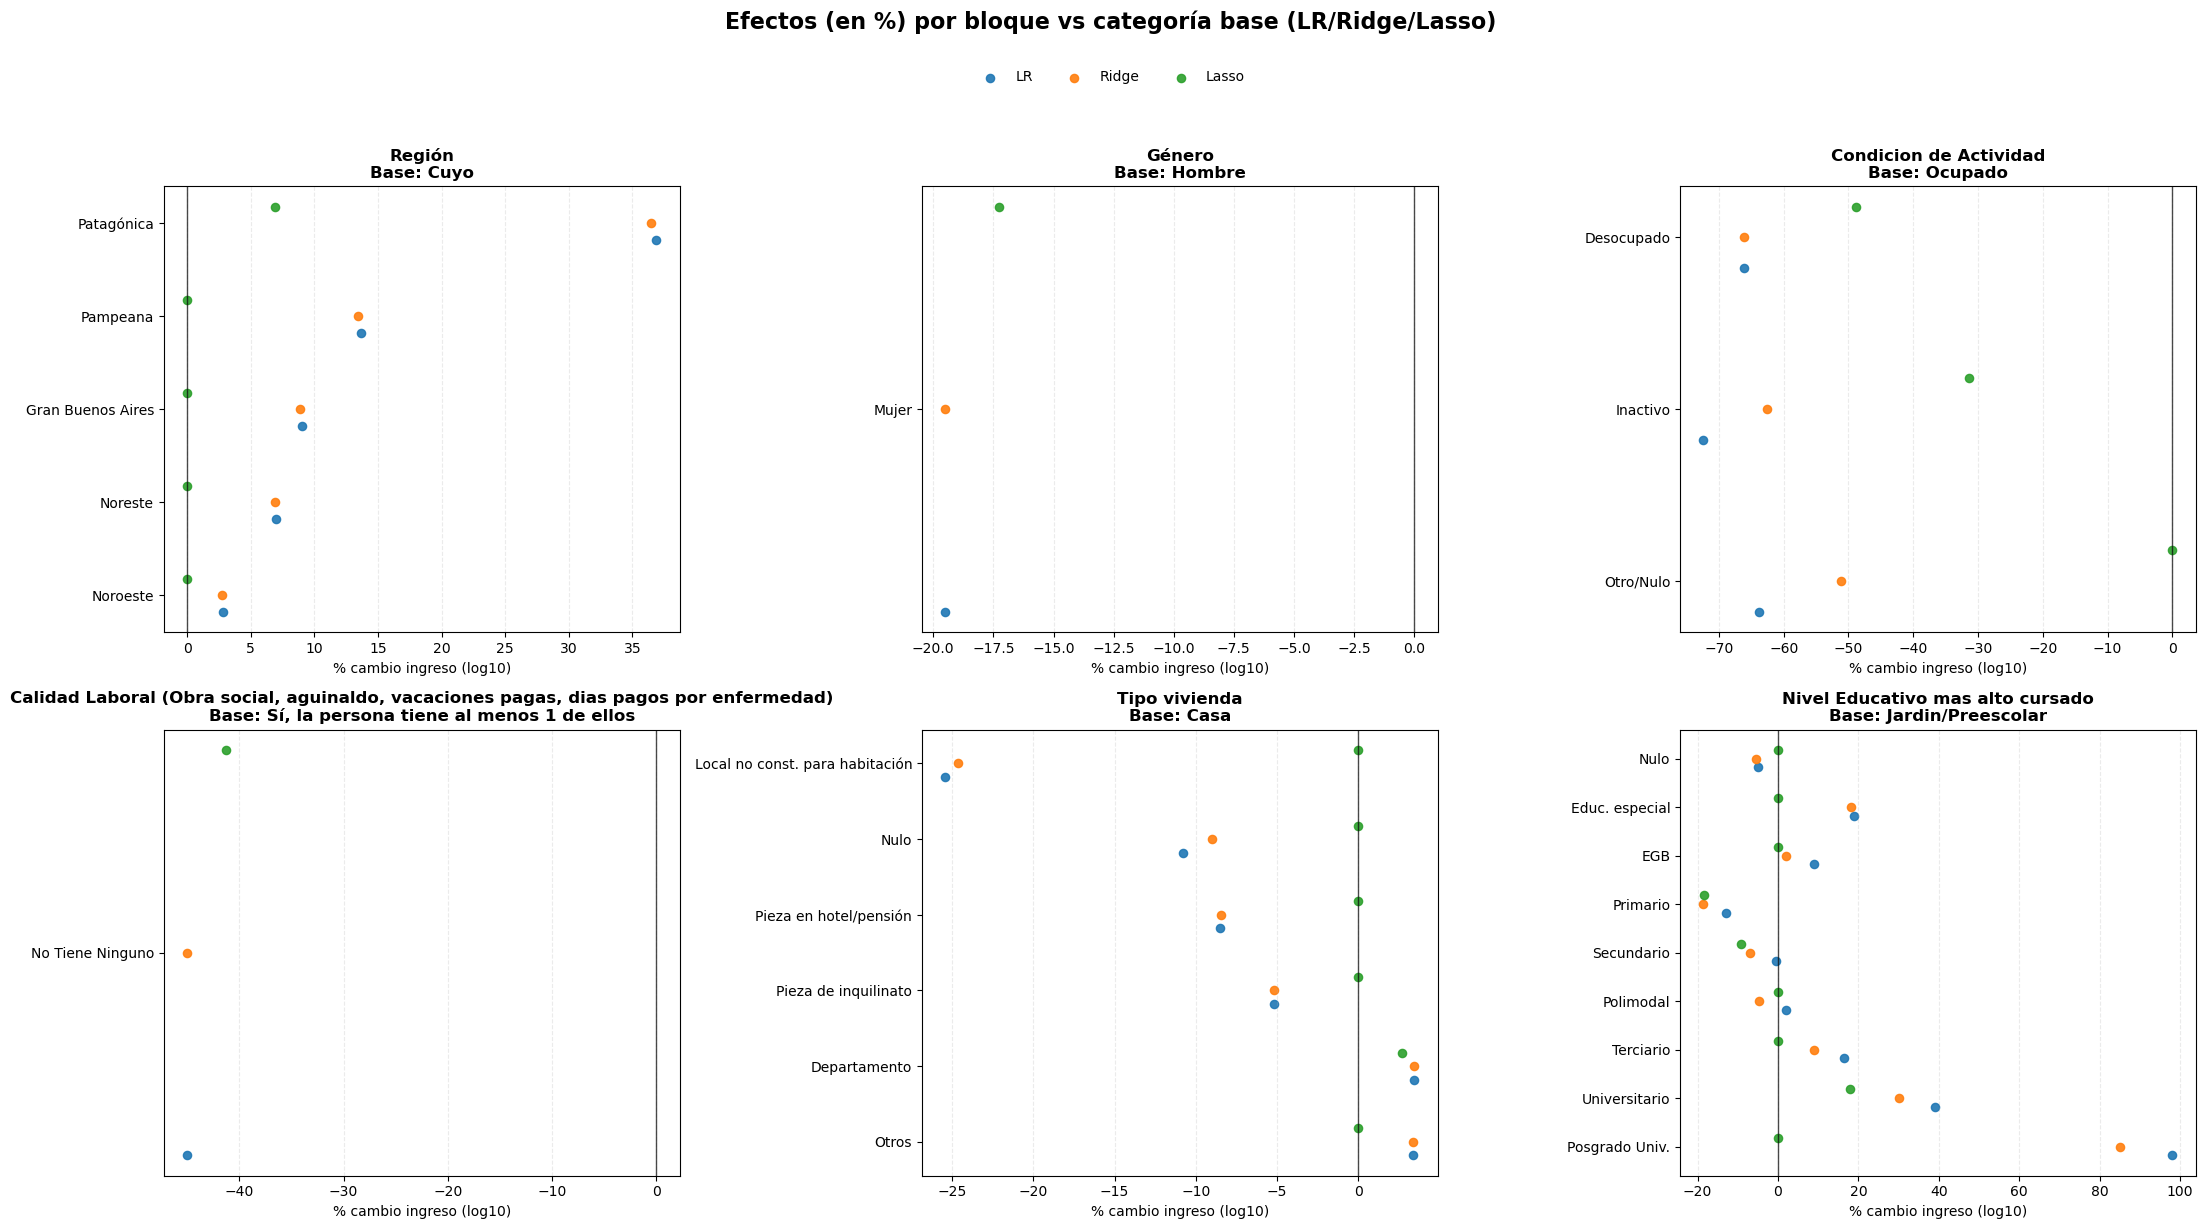

In [106]:
blocks = [
    {"title": "Región",  "prefix": "cat__Region_",  "base_note": "Cuyo"},
    {"title": "Género",  "prefix": "cat__P02_",     "base_note": "Hombre"},
    {"title": "Condicion de Actividad", "prefix": "cat__CONDACT_", "base_note": "Ocupado"},
    {"title": "Calidad Laboral (Obra social, aguinaldo, vacaciones pagas, dias pagos por enfermedad)", "prefix": "cat__PP07G_59_", "base_note": "Sí, la persona tiene al menos 1 de ellos"},
    {"title": "Tipo vivienda",  "prefix": "cat__V01_", "base_note": "Casa"},
    {"title": "Nivel Educativo mas alto cursado",    "prefix": "cat__P09_", "base_note": "Jardin/Preescolar", 
        "order": [
            "Nulo",
            "Educ. especial",
            "EGB",
            "Primario",
            "Secundario",
            "Polimodal",
            "Terciario",
            "Universitario",
            "Posgrado Univ."
        ],
    },
]

plot_coef_blocks_2x3(
    coef_df=df_coefs,         # DF con columnas feature, LR, Ridge, Lasso
    blocks=blocks,
    model_cols=("LR", "Ridge", "Lasso"),
    top_k=12,
    use_percent=True,                 
    sort_by="Ridge",
    figsize=(22, 12),
    suptitle="Efectos (en %) por bloque vs categoría base (LR/Ridge/Lasso)"
)

